## Carga inicial del dataset y revisión básica

In [9]:
import pandas as pd

# Carga del dataset principal
df = pd.read_csv("model_train_transaction_merchants_final_acotado.csv")

# Vista preliminar
print(df.head())


           card_id first_active_month  feature_1  feature_2    target  \
0  C_ID_75043e4761            2016-10          3          2  0.736966   
1  C_ID_0e592ed30e            2017-10          5          1  0.428827   
2  C_ID_9fd520b31a            2017-11          5          1 -0.767089   
3  C_ID_553580dba0            2016-11          5          2 -0.189975   
4  C_ID_726016d758            2016-04          2          2  0.015637   

  authorized_flag_mode  installments_mode  merchant_category_id_mode  \
0                    Y                  1                        307   
1                    Y                  1                        705   
2                    Y                  1                        683   
3                    Y                  0                        705   
4                    Y                  0                        705   

  merchant_id_mode  avg_purchase_amount  ...  avg_active_months_lag12_mode  \
0  M_ID_faa4560000            -0.576808  ...      

## Preparación del dataset y entrenamiento inicial de modelos

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Eliminar columnas no numéricas o poco útiles para el modelo
df = df.drop(columns=["card_id", "merchant_id_mode", "first_active_month"])

# Codificación de variables categóricas
cat_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Separación de variables predictoras y target
X = df.drop(columns=["target"])
y = df["target"]

# Muestra de entrenamiento reducida para prototipado rápido
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.2, random_state=42)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Definición de modelos ordenados por complejidad
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}


## Entrenamiento inicial y evaluación de los modelos

In [11]:
# Evaluación de modelos sin selección de variables
resultados_baseline = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    resultados_baseline.append((nombre, rmse, r2))
    print(f"\nModelo: {nombre}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")



Modelo: Regresión Lineal
RMSE: 1.6941
R2 Score: 0.0030

Modelo: Árbol de Decisión
RMSE: 2.4563
R2 Score: -1.0961

Modelo: Random Forest
RMSE: 1.7161
R2 Score: -0.0231

Modelo: XGBoost
RMSE: 1.7411
R2 Score: -0.0530


## Análisis de correlación con el target

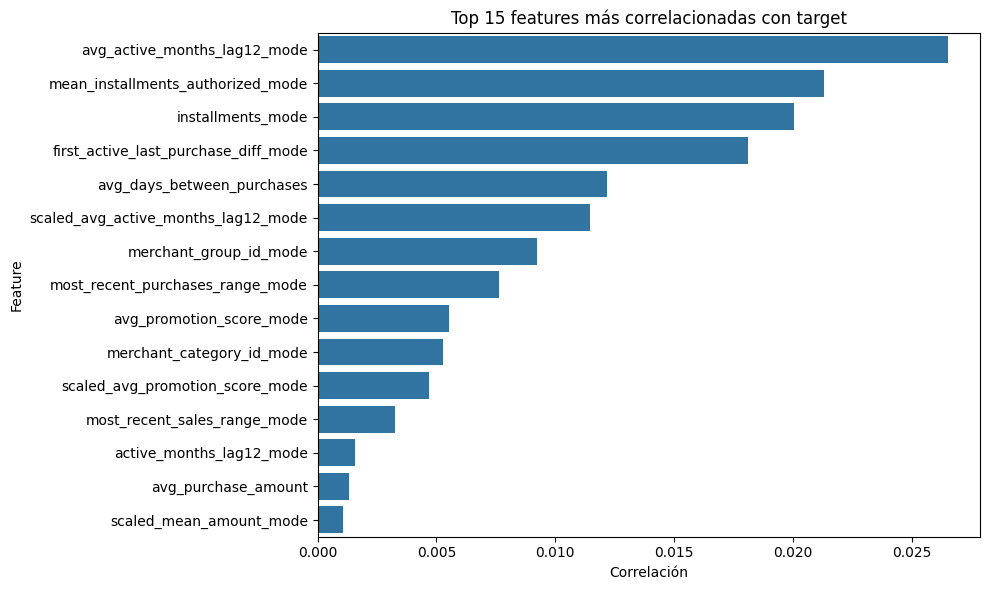

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cor = df.corr(numeric_only=True)
target_corr = cor["target"].drop("target").sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=target_corr.values[:15], y=target_corr.index[:15])
plt.title("Top 15 features más correlacionadas con target")
plt.xlabel("Correlación")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Reducción de dimensionalidad (selección de top 15 features)

In [13]:
# Selección de las 15 variables más correlacionadas
top_features = target_corr.sort_values(ascending=False).head(15).index.tolist()
X_filtered = X_sample[top_features]

# División train/test con dataset reducido
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_sample, test_size=0.2, random_state=42)


## Entrenamiento con top features seleccionados

In [14]:
# Evaluación de modelos usando solo las 15 features más relevantes
resultados_filtrados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    resultados_filtrados.append((nombre, rmse, r2))
    print(f"\nModelo con top features: {nombre}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")



Modelo con top features: Regresión Lineal
RMSE: 1.6965
R2 Score: 0.0002

Modelo con top features: Árbol de Decisión
RMSE: 2.4707
R2 Score: -1.1207

Modelo con top features: Random Forest
RMSE: 1.7293
R2 Score: -0.0388

Modelo con top features: XGBoost
RMSE: 1.7338
R2 Score: -0.0443


## Comparación visual de los modelos antes y después del filtrado

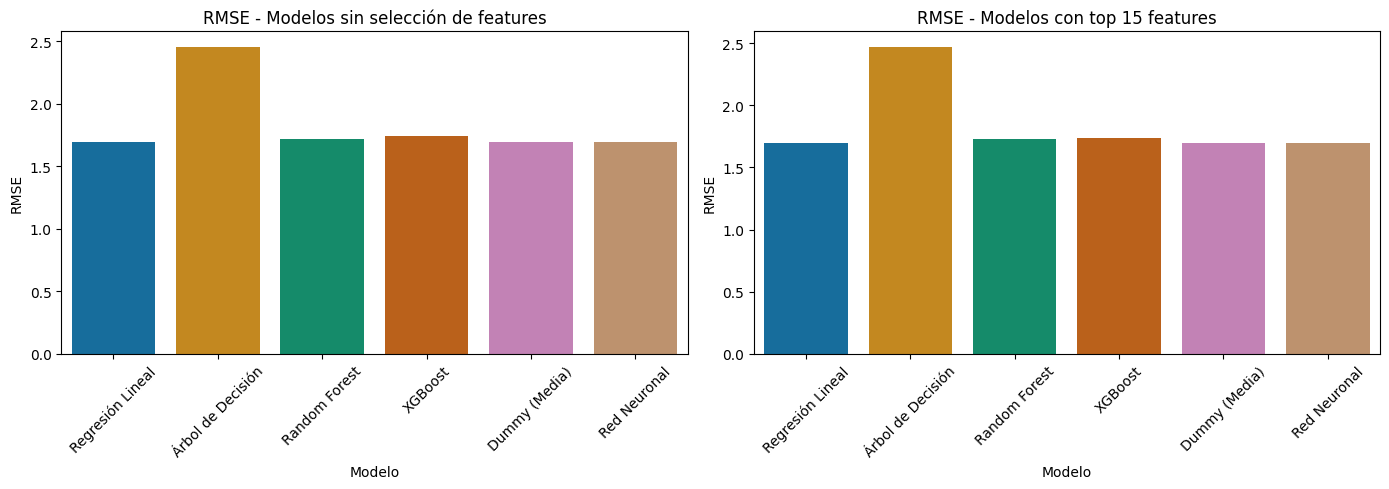

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear dataframes con los resultados
baseline_df = pd.DataFrame(resultados_baseline, columns=["Modelo", "RMSE", "R2"])
filtrado_df = pd.DataFrame(resultados_filtrados, columns=["Modelo", "RMSE", "R2"])
# Agregar dummy a resultados
baseline_df.loc[len(baseline_df.index)] = ["Dummy (Media)", rmse_dummy, r2_dummy]
filtrado_df.loc[len(filtrado_df.index)] = ["Dummy (Media)", rmse_dummy, r2_dummy]
# Agregar resultados a tabla
filtrado_df.loc[len(filtrado_df.index)] = ["Red Neuronal", rmse_nn, r2_nn]
baseline_df.loc[len(baseline_df.index)] = ["Red Neuronal", rmse_nn, r2_nn]


# Paleta de colores personalizada
colores = sns.color_palette("colorblind", len(baseline_df))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Sin selección de features
sns.barplot(data=baseline_df, x="Modelo", y="RMSE", ax=axs[0], palette=colores)
axs[0].set_title("RMSE - Modelos sin selección de features")
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)

# Gráfico 2: Con top 15 features
sns.barplot(data=filtrado_df, x="Modelo", y="RMSE", ax=axs[1], palette=colores)
axs[1].set_title("RMSE - Modelos con top 15 features")
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [17]:
from sklearn.dummy import DummyRegressor

# Dummy baseline con promedio
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)

rmse_dummy = np.sqrt(mean_squared_error(y_test, y_dummy_pred))
r2_dummy = r2_score(y_test, y_dummy_pred)

print("Modelo Dummy (Media):")
print(f"RMSE: {rmse_dummy:.4f}")
print(f"R2 Score: {r2_dummy:.4f}")


Modelo Dummy (Media):
RMSE: 1.6968
R2 Score: -0.0002


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Escalado (importante para redes neuronales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)  # Usa tus top 15 features

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_sample, test_size=0.2, random_state=42)

# Definir modelo secuencial
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Salida continua
])

# Compilar modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar con early stopping
es = EarlyStopping(patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, callbacks=[es], verbose=0)

# Evaluar en test
y_pred_nn = model.predict(X_test).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("Red Neuronal (MLP):")
print(f"RMSE: {rmse_nn:.4f}")
print(f"R2 Score: {r2_nn:.4f}")


216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
Red Neuronal (MLP):
RMSE: 1.6940
R2 Score: 0.0031
